# Chapter 1 : Numerical vs Numerical

## Scatter Plot - The Foundation
A scatter plot places every row as a dot : X-axis = column A, Y-axis = column B. The pattern of dots reveals the relationship.

In [2]:
import pandas as pd , numpy as np , matplotlib.pyplot as plt , seaborn as sns
from scipy import stats

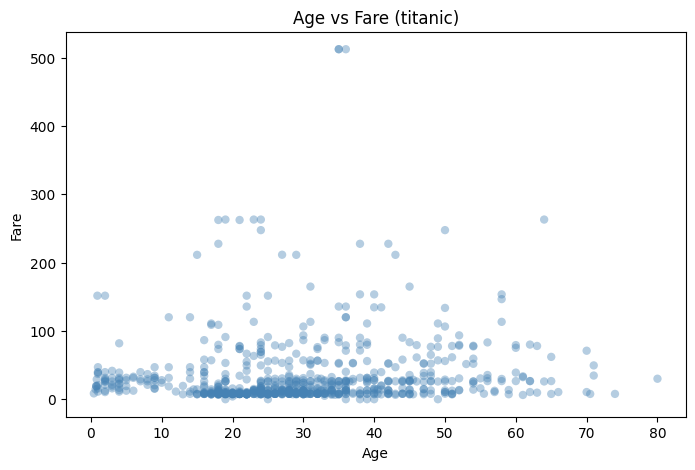

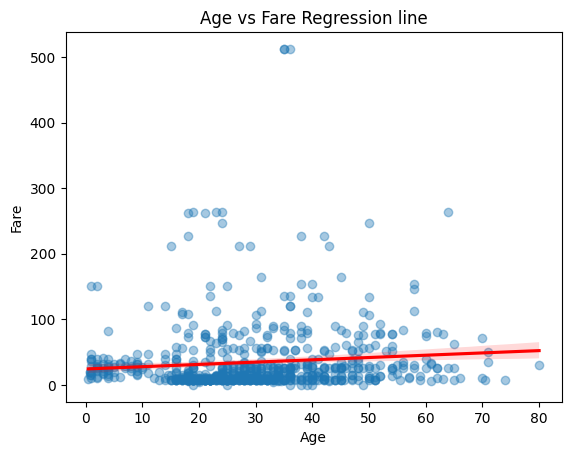

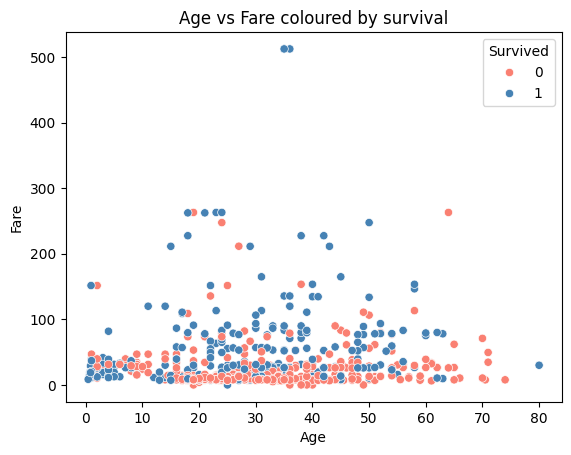

In [4]:
df = pd.read_csv('../data/titanic.csv')

# basic scatter plot 
plt.figure(figsize = (8,5))
plt.scatter(df['Age'] , df['Fare'] , alpha = 0.4 , color = 'steelblue' , edgecolors = 'none')
plt.xlabel('Age')
plt.ylabel('Fare')
plt.title('Age vs Fare (titanic)')
plt.show()


# seaborn version with regression line 
sns.regplot(x = 'Age' , y = 'Fare' , data = df , scatter_kws = {'alpha' : 0.4} , 
           line_kws = {'color' : 'red'})
plt.title('Age vs Fare Regression line')
plt.show()

# with hue (colour by a third variable)
sns.scatterplot(x = 'Age' , y = 'Fare' , hue = 'Survived' , data = df , 
               palette = {0 : 'salmon' , 1: 'steelblue'})
plt.title('Age vs Fare coloured by survival')
plt.show()

## Correlation - Quantifying the relationship 
The scatter shows the shape; correlation gives you a number. Pearson's r ranges from −1 (perfect negative) to +1 (perfect positive), with 0 meaning no linear relationship.

In [7]:
# pearson correlation (linear relationship)
r , p_value = stats.pearsonr(df['Age'].dropna() , df['Fare'][df['Age'].notna()])
print(f"pearson r : {r:.4f}")
print(f"p_value : {p_value:.4f}")


print("--- "*20)


# spearman correlation (handles outliners better) 
r_s , p_s = stats.spearmanr(df['Age'].dropna() , df['Fare'][df['Age'].notna()])
print(f"spearman r : {r_s:.4f}")
# spearman is rank based less sensitive to extreme outliners 

print("--- "*20)


# quick correlation between two columns 
print(df[['Age' , 'Fare' , 'SibSp' , 'Parch']].corr())
# ── Interpreting r values ─────────────────────────────────────
# |r| < 0.1  → negligible
# |r| 0.1-0.3 → weak
# |r| 0.3-0.5 → moderate
# |r| 0.5-0.7 → strong
# |r| > 0.7  → very strong

pearson r : 0.0961
p_value : 0.0102
--- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- 
spearman r : 0.1351
--- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- 
            Age      Fare     SibSp     Parch
Age    1.000000  0.096067 -0.308247 -0.189119
Fare   0.096067  1.000000  0.159651  0.216225
SibSp -0.308247  0.159651  1.000000  0.414838
Parch -0.189119  0.216225  0.414838  1.000000


The critical distinction between Pearson and Spearman: if your data has outliers (like Titanic fares — a few passengers paid £500+), Spearman is more robust because it works on ranks, not raw values. Pearson can be massively distorted by a single outlier.

# Correlation Martrix - The Full Picture
The correlation matrix shows pairwise correlations between all numerical columns simultaneously.

          Survived  Pclass    Age  SibSp  Parch   Fare
Survived     1.000  -0.338 -0.077 -0.035  0.082  0.257
Pclass      -0.338   1.000 -0.369  0.083  0.018 -0.549
Age         -0.077  -0.369  1.000 -0.308 -0.189  0.096
SibSp       -0.035   0.083 -0.308  1.000  0.415  0.160
Parch        0.082   0.018 -0.189  0.415  1.000  0.216
Fare         0.257  -0.549  0.096  0.160  0.216  1.000


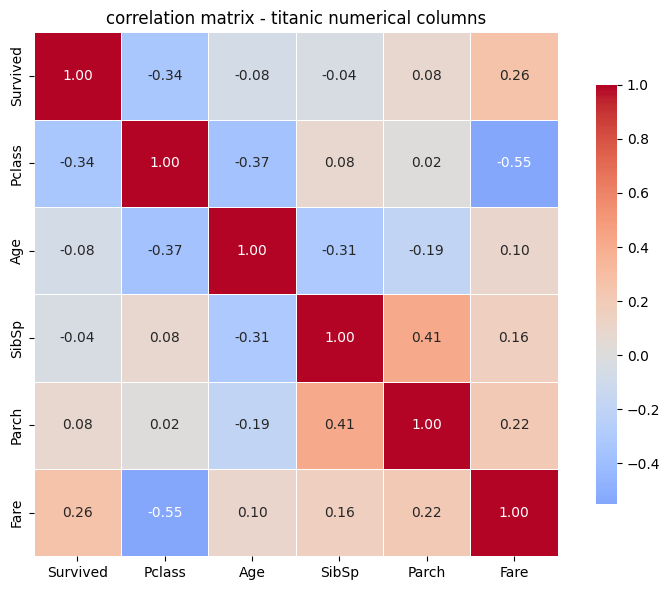

strong correlations
Pclass    Fare       -0.549500
          Age        -0.369226
Survived  Pclass     -0.338481
Age       SibSp      -0.308247
SibSp     Parch       0.414838
Survived  Survived    1.000000
dtype: float64


In [8]:
# full correlation matrix
num_cols = ['Survived' , 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare' ]
corr_matrix = df[num_cols].corr()
print(corr_matrix.round(3))

# heatmap visualisation
plt.figure(figsize = (8,6))
sns.heatmap(
    corr_matrix, 
    annot = True, 
    fmt = '.2f', 
    cmap = 'coolwarm', 
    center = 0, 
    square = True, 
    linewidth = 0.5, 
    cbar_kws={'shrink' : 0.8}
    
)
plt.title('correlation matrix - titanic numerical columns')
plt.tight_layout()
plt.show()


# Highlight only strong correlations 
strong = corr_matrix[abs(corr_matrix) > 0.3]
print("strong correlations")
print(strong.stack().drop_duplicates().sort_values())

# Chapter 2 : Categorical vs Numerical

This answers : "does the value of a numerical column differ meaningfully across categories?" E.g., "Do survivors have different ages from non-survivors?"

## Grouped Boxplot and Violin Plot

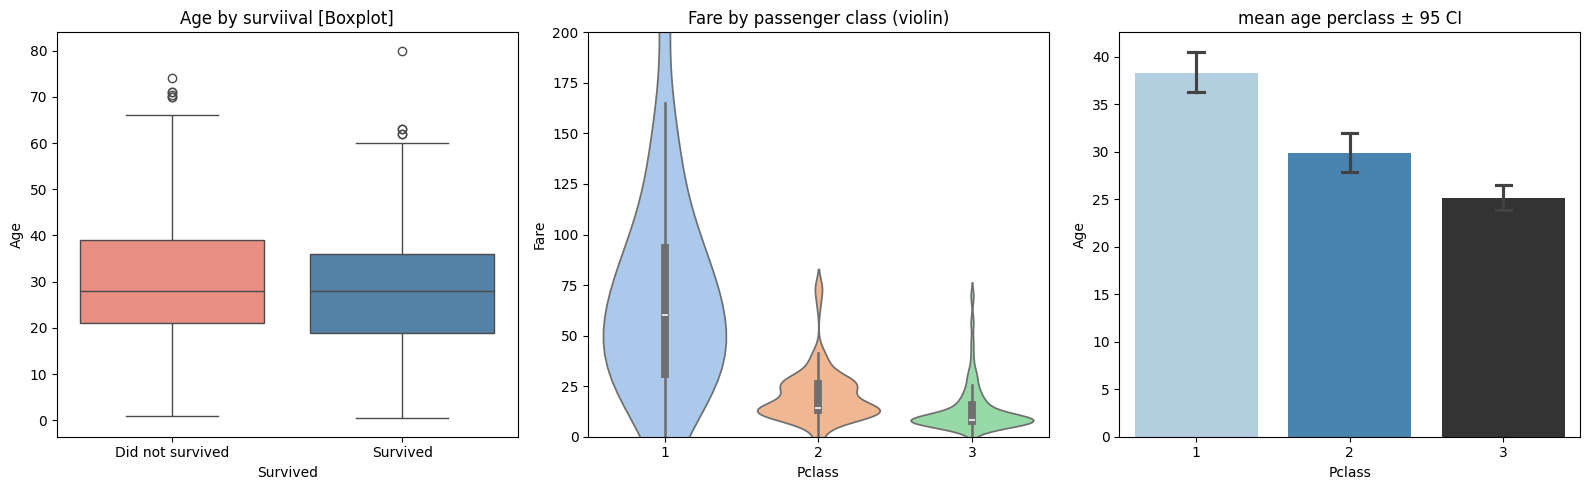

In [19]:
df['Survived'] = df['Survived'].astype(int)
fig , axes = plt.subplots(1 , 3 , figsize = (16 , 5)) 

# gruped subplot 
sns.boxplot(x = "Survived" , y = "Age" , data = df , ax = axes[0] , 
           hue = 'Survived' , palette = {0 : 'salmon' , 1 : 'steelblue'} , legend = False)
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Did not survived' , 'Survived'])
axes[0].set_title('Age by surviival [Boxplot]')


# grouped violin
sns.violinplot(x = 'Pclass' , y = 'Fare' , data = df , ax = axes[1] , 
              hue = 'Pclass' , palette = 'pastel' , inner = 'box' , legend = False)
axes[1].set_title('Fare by passenger class (violin)')
axes[1].set_ylim(0 , 200)

# barrplot shows mean 95 CI 
sns.barplot(x = 'Pclass' , y = 'Age' , data = df , ax = axes[2] ,
            hue = 'Pclass' , palette = 'Blues_d' , errorbar=('ci', 95) , capsize = 0.1 , legend = False
           )
axes[2].set_title("mean age perclass ± 95 CI")
plt.tight_layout()
plt.show()

The grouped barplot shows mean + confidence interval, which is different from the boxplot (which shows median + IQR). Use the boxplot when you suspect outliers; use the barplot when you want to communicate average differences with statistical uncertainty.

## Statistical Testing for Cat vs Num

In [25]:
# After seeing the boxplot, you want to know: is this difference REAL?
# Use t-test for 2 groups, ANOVA for 3+ groups

from scipy import stats

# t - test : do surviviors and non survivors have different ages ? 
survived_age = df[df['Survived'] == 1]['Age'].dropna()
non_survived_age = df[df['Survived'] == 0]['Age'].dropna()

t_stats , p_value = stats.ttest_ind(survived_age , non_survived_age)
print(f"survived mean age : {survived_age.mean():.2f}")
print(f"non survived mean age :{non_survived_age.mean():.2f}")
print(f"t-statistic : {t_stats:.4f}")
print(f"p_value : {p_value:.4f}")

# anova (does age differ acrross all ages )
class1 = df[df['Pclass'] == 1]['Age'].dropna()
class2 = df[df['Pclass'] == 2]['Age'].dropna()
class3 = df[df['Pclass'] == 3]['Age'].dropna()

f_stat , p_anova = stats.f_oneway(class1 , class2 , class3)
print(f"class means = 1st = {class1.mean():.1f} , 2nd = {class2.mean():.1f} , 3rd = {class3.mean():.1f}")
print(f"f-statistic = {f_stat:.4f} , p_value = {p_anova:.4f}")


survived mean age : 28.34
non survived mean age :30.63
t-statistic : -2.0667
p_value : 0.0391
class means = 1st = 38.2 , 2nd = 29.9 , 3rd = 25.1
f-statistic = 57.4435 , p_value = 0.0000


# Chapter 3: Categorical vs Categorical
This answers: "do two categories tend to appear together?" E.g., "Does survival rate differ between male and female passengers?"

## Crosstab — The Foundation

In [27]:
# basic crosstab 
ct = pd.crosstab(df['Sex'] , df['Survived'])
print(ct)


print("--- "*20)

# with margins
ct_margins = pd.crosstab(df['Sex'] , df['Survived'] , margins = True , margins_name= ' Total')
print(ct_margins)

print("--- "*20)

# normalized (percentage for each row)
ct_pct = pd.crosstab(df['Sex'] , df['Survived'] , normalize = 'index')
print(ct_pct.round(3) * 100)

print("--- "*20)


# chi-square test : (is the association statistically significant?)
chi2, p, dof, expected = stats.chi2_contingency(ct)
print(f"chi_square = {chi2:.2f}")
print(f"p_value = {p:.2e}")
print(f"degrees of freedom = {dof}")

Survived    0    1
Sex               
female     81  233
male      468  109
--- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- 
Survived    0    1   Total
Sex                       
female     81  233     314
male      468  109     577
 Total    549  342     891
--- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- 
Survived     0     1
Sex                 
female    25.8  74.2
male      81.1  18.9
--- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- --- 
chi_square = 260.72
p_value = 1.20e-58
degrees of freedom = 1


## Heatmap of Crosstab + Stacked Bar

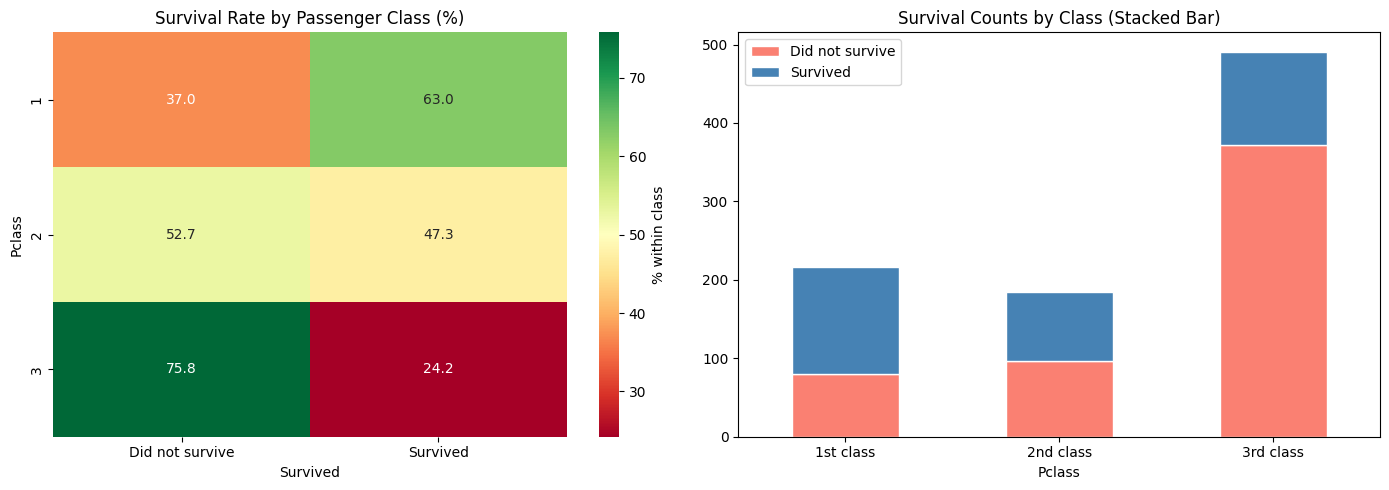

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# - Heatmap of crosstab percentages 
ct_pct = pd.crosstab(df['Pclass'], df['Survived'], normalize='index') * 100
sns.heatmap(ct_pct, annot=True, fmt='.1f', cmap='RdYlGn',
            ax=axes[0], cbar_kws={'label': '% within class'})
axes[0].set_title('Survival Rate by Passenger Class (%)')
axes[0].set_xticklabels(['Did not survive', 'Survived'])

# - Stacked bar chart 
ct_raw = pd.crosstab(df['Pclass'], df['Survived'])
ct_raw.plot(kind='bar', stacked=True, ax=axes[1],
            color=['salmon', 'steelblue'], edgecolor='white')
axes[1].set_title('Survival Counts by Class (Stacked Bar)')
axes[1].set_xticklabels(['1st class', '2nd class', '3rd class'], rotation=0)
axes[1].legend(['Did not survive', 'Survived'])

plt.tight_layout()
plt.show()


# Chapter 4: Multivariate Analysis
Multivariate means looking at 3 or more variables at the same time. This is where you move from finding individual relationships to understanding the full structure of your data.

## Pairplot — The Grid of All Combinations

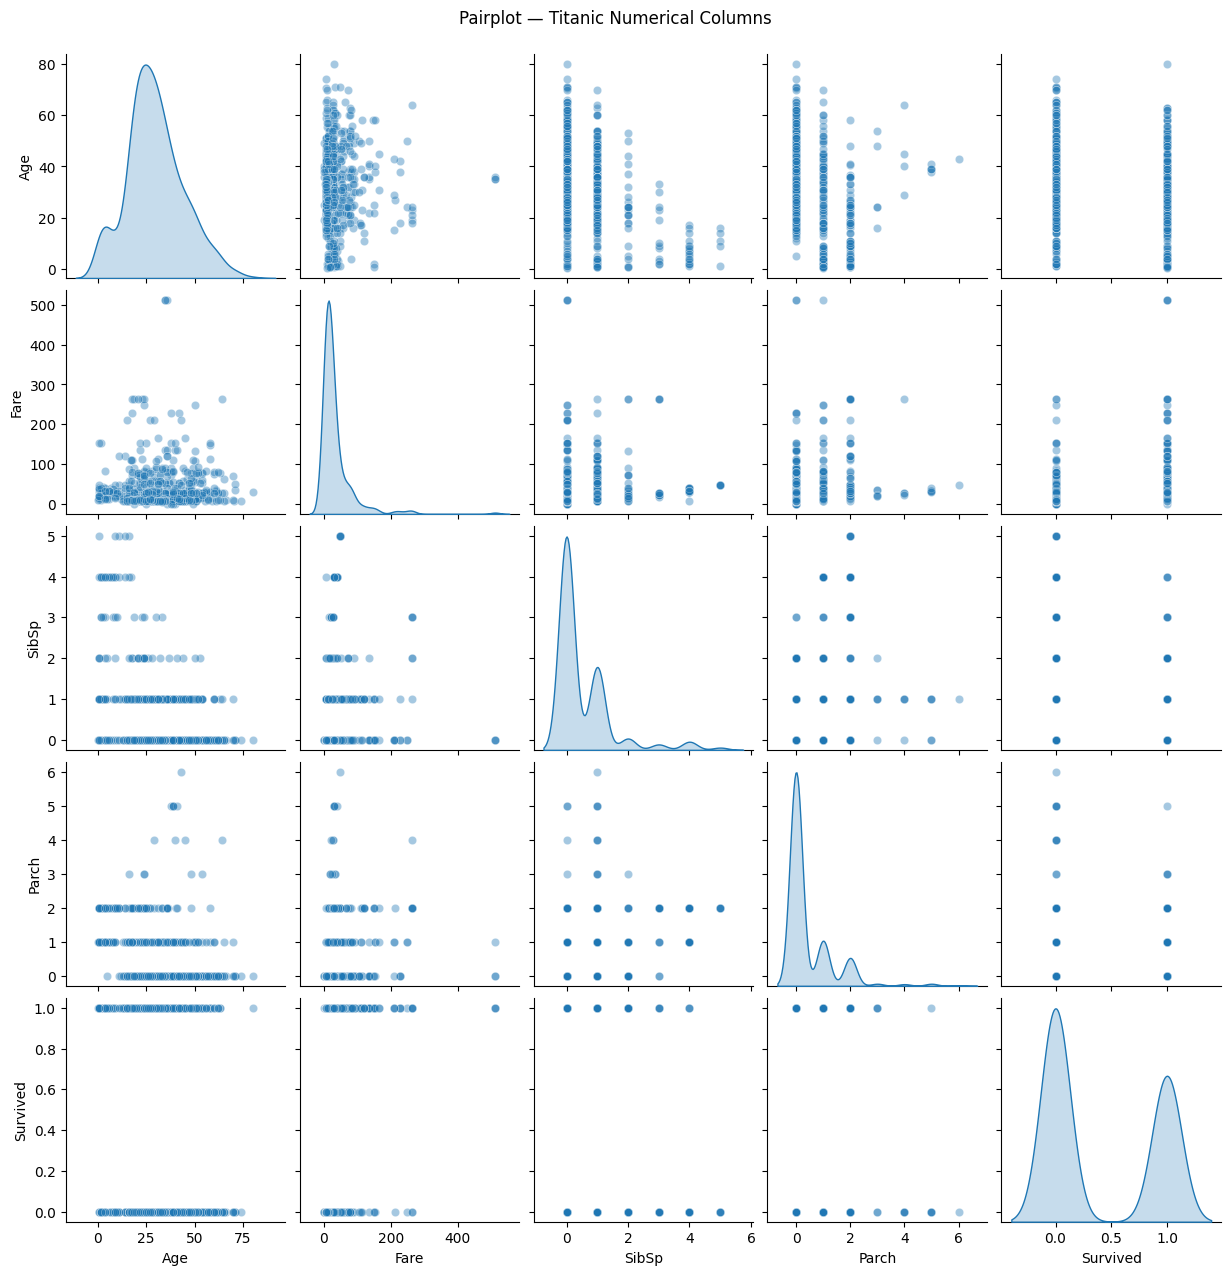

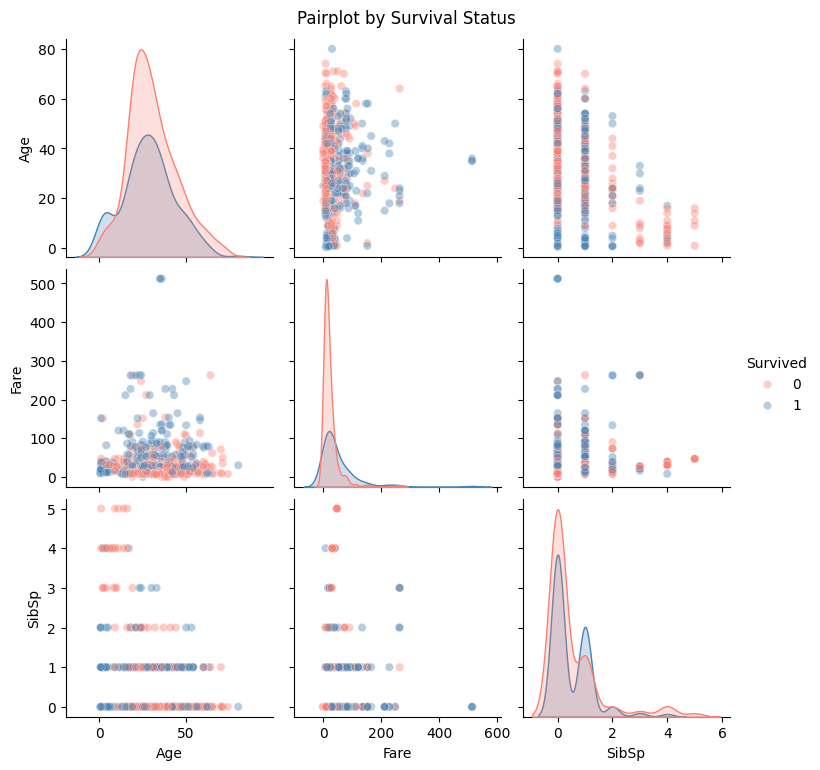

In [31]:
# paiplot shows scatterplots for every two pair numerical columns 
# with histograms / kde on diagonal 

num_df = df[['Age', 'Fare', 'SibSp', 'Parch', 'Survived']].dropna()

# Basic pairplot
sns.pairplot(num_df, diag_kind='kde', plot_kws={'alpha': 0.4})
plt.suptitle('Pairplot — Titanic Numerical Columns', y=1.02)
plt.show()

# ─ Pairplot with hue (game-changing!) 
sns.pairplot(num_df, hue='Survived',
             diag_kind='kde',
             palette={0: 'salmon', 1: 'steelblue'},
             plot_kws={'alpha': 0.4},
             vars=['Age', 'Fare', 'SibSp'])
plt.suptitle('Pairplot by Survival Status', y=1.02)
plt.show()

# Interpretation guide for pairplot:
# - Diagonal: distribution of each variable (KDE or hist)
# - Off-diagonal: scatter of variable pair
# - With hue: separation between groups on each scatter
# - Look for: clear cluster separation → that pair is informative
# - Diagonal KDE overlap between groups → variable is less discriminating

## Bubble Chart - 3 Numerical Variables at Once

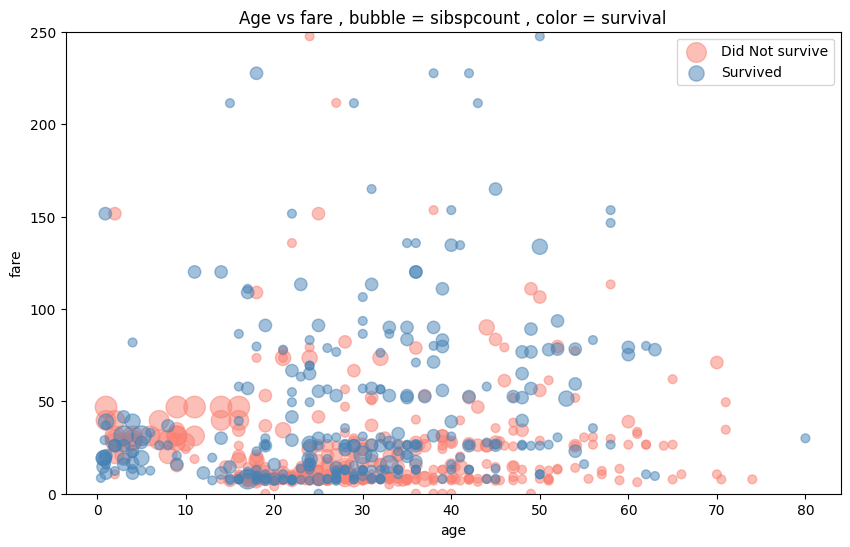

In [36]:
# scatter plot + size = 3 variables on one chart 
# x = age , y = fare , bubble_sized = Sibsp , color = survived 

fig , ax = plt.subplots(figsize = (10 , 6))

for survived , group in df.groupby('Survived'): 
    ax.scatter(
        group['Age'],
        group['Fare'], 
        s = (group['SibSp'] + 1) * 40 , 
        alpha = 0.5 , 
        label = 'Survived' if survived else 'Did Not survive' , 
        c = 'steelblue' if survived else 'salmon'
    )
ax.set_xlabel('age')
ax.set_ylabel('fare')
ax.set_ylim(0 , 250)
ax.legend()
ax.set_title('Age vs fare , bubble = sibspcount , color = survival')
plt.show()

## Parallel Coordinates - Comparing Profiles Across Many Variables

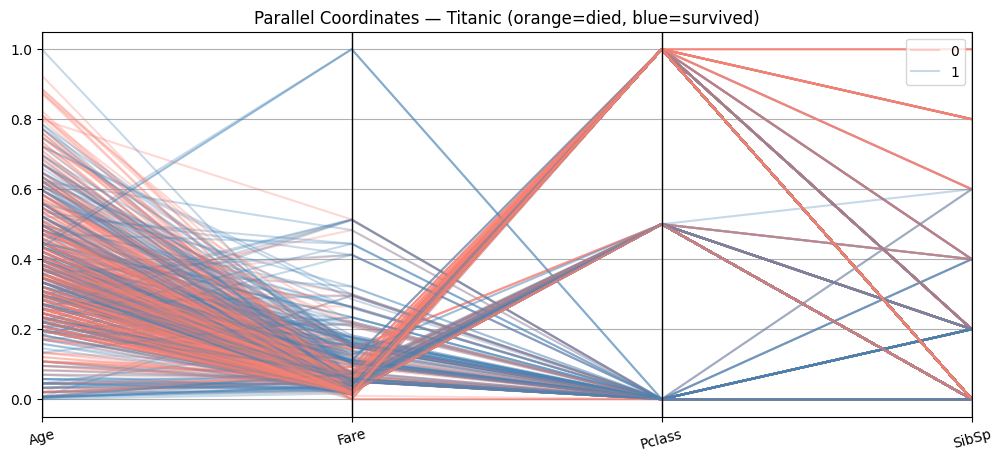

In [37]:
from pandas.plotting import parallel_coordinates

# Parallel coordinates shows a line per row
# Each vertical axis is one column
# Lines cluster together for similar rows

pc_df = df[['Age', 'Fare', 'Pclass', 'SibSp', 'Survived']].dropna().copy()

# normalize each column for 0 - 1 for comparable axes 
for col in ['Age', 'Fare', 'Pclass', 'SibSp']:
    pc_df[col] = (pc_df[col] - pc_df[col].min()) / (pc_df[col].max() - pc_df[col].min())

plt.figure(figsize=(12, 5))
parallel_coordinates(pc_df, 'Survived',
                     color=['salmon', 'steelblue'],
                     alpha=0.3)
plt.title('Parallel Coordinates — Titanic (orange=died, blue=survived)')
plt.xticks(rotation=15)
plt.show()
# What to look for:
# Lines that CROSS between two axes → the relationship is NEGATIVE (when one goes up, other goes down)
# Lines that run PARALLEL between two axes → POSITIVE relationship
# One colour clustering at top/bottom of an axis → that variable separates the groups

# Chapter 5 : How to Interpret Relationships - The Full Framework

In [ ]:
###  How to Read a Parallel Coordinates Plot

| Pattern | What It Means |
|---------|--------------|
| **Lines that CROSS** between two axes | **Negative relationship** — when one variable goes up, the other goes down |
| **Lines that run PARALLEL** between two axes | **Positive relationship** — both variables move in the same direction |
| **One colour clustering at top/bottom** of an axis | That variable **separates the groups** — strong discriminating feature |

---

> 💡 **What to look for in one glance:**
> - Lots of **crossing lines** between two axes → those features are negatively correlated
> - Mostly **parallel lines** → those features carry similar information (may be redundant)
> - A colour **clearly separating** at one axis → that feature is **important for classification**

---

> ⚠️ **Tip:** Parallel coordinates works best when you colour by the 
> **target variable** (e.g. `Survived`). That way you instantly see 
> which features best separate survivors from non-survivors.